# 🚀 Gravity Assist Simulation
## Step 3: Moving Jupiter vs Fixed Jupiter Comparison

### Objective
木星が動いている場合と、最接近時の位置で固定されている場合を比較し、
重力アシストによる速度変化を調べる。

### Question
- 木星が動くことによって、探査機の速度変化はどう変わるのか？
- 単なる重力散乱と、重力アシストの違いは何か？

In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ----------------------------
# Parameters
# ----------------------------
mu_sun = 1.0
mu_jupiter = 0.02

R_jupiter = 2.0
omega_jupiter = np.sqrt(mu_sun / R_jupiter**3)

dt = 0.001
steps = 30000

In [3]:
def jupiter_position(t):
    xj = R_jupiter * np.cos(omega_jupiter * t)
    yj = R_jupiter * np.sin(omega_jupiter * t)
    return xj, yj

In [18]:
def simulate_flyby(mu_sun, mu_jupiter, x, y, vx, vy, dt, steps):
    x_list = []
    y_list = []
    xj_list = []
    yj_list = []
    speed_list = []
    time_list = []
    r_jup_list = []

    t = 0.0

    for _ in range(steps):
        xj, yj = jupiter_position(t)

        r_sun = np.sqrt(x**2 + y**2)

        dxj = x - xj
        dyj = y - yj
        r_jup = np.sqrt(dxj**2 + dyj**2)

        ax_sun = -mu_sun * x / r_sun**3
        ay_sun = -mu_sun * y / r_sun**3

        ax_jup = -mu_jupiter * dxj / r_jup**3
        ay_jup = -mu_jupiter * dyj / r_jup**3

        ax = ax_sun + ax_jup
        ay = ay_sun + ay_jup

        vx += ax * dt
        vy += ay * dt

        x += vx * dt
        y += vy * dt

        speed = np.sqrt(vx**2 + vy**2)

        x_list.append(x)
        y_list.append(y)
        xj_list.append(xj)
        yj_list.append(yj)
        speed_list.append(speed)
        time_list.append(t)
        r_jup_list.append(r_jup)

        t += dt

    return x_list, y_list, xj_list, yj_list, speed_list, time_list, r_jup_list

In [13]:
# ----------------------------
# Initial conditions
# ----------------------------
x0 = 2.2
y0 = -0.6
vx0 = 0
vy0 = 0.9

In [19]:
x_list, y_list, xj_list, yj_list, speed_list, time_list, r_jup_list = simulate_flyby(
    mu_sun, mu_jupiter, x0, y0, vx0, vy0, dt, steps
)

In [20]:
closest_index = np.argmin(r_jup_list)

t_close = time_list[closest_index]
xj_close = xj_list[closest_index]
yj_close = yj_list[closest_index]
r_close = r_jup_list[closest_index]

print("Closest approach index:", closest_index)
print("Closest approach time:", t_close)
print("Closest Jupiter position:", (xj_close, yj_close))
print("Closest distance to Jupiter:", r_close)

Closest approach index: 2079
Closest approach time: 2.078999999999882
Closest Jupiter position: (np.float64(1.4836112130078507), np.float64(1.3412299462200261))
Closest distance to Jupiter: 0.13696101326092908


In [21]:
def simulate_flyby_fixed_jupiter(mu_sun, mu_jupiter, x, y, vx, vy, dt, steps, xj_fixed, yj_fixed):
    x_list = []
    y_list = []
    speed_list = []
    time_list = []
    r_jup_list = []

    t = 0.0

    for _ in range(steps):
        xj = xj_fixed
        yj = yj_fixed

        r_sun = np.sqrt(x**2 + y**2)

        dxj = x - xj
        dyj = y - yj
        r_jup = np.sqrt(dxj**2 + dyj**2)

        ax_sun = -mu_sun * x / r_sun**3
        ay_sun = -mu_sun * y / r_sun**3

        ax_jup = -mu_jupiter * dxj / r_jup**3
        ay_jup = -mu_jupiter * dyj / r_jup**3

        ax = ax_sun + ax_jup
        ay = ay_sun + ay_jup

        vx += ax * dt
        vy += ay * dt

        x += vx * dt
        y += vy * dt

        speed = np.sqrt(vx**2 + vy**2)

        x_list.append(x)
        y_list.append(y)
        speed_list.append(speed)
        time_list.append(t)
        r_jup_list.append(r_jup)

        t += dt

    return x_list, y_list, speed_list, time_list, r_jup_list

In [22]:
x_fixed_list, y_fixed_list, speed_fixed_list, time_fixed_list, r_fixed_jup_list = simulate_flyby_fixed_jupiter(
    mu_sun, mu_jupiter, x0, y0, vx0, vy0, dt, steps, xj_close, yj_close
)

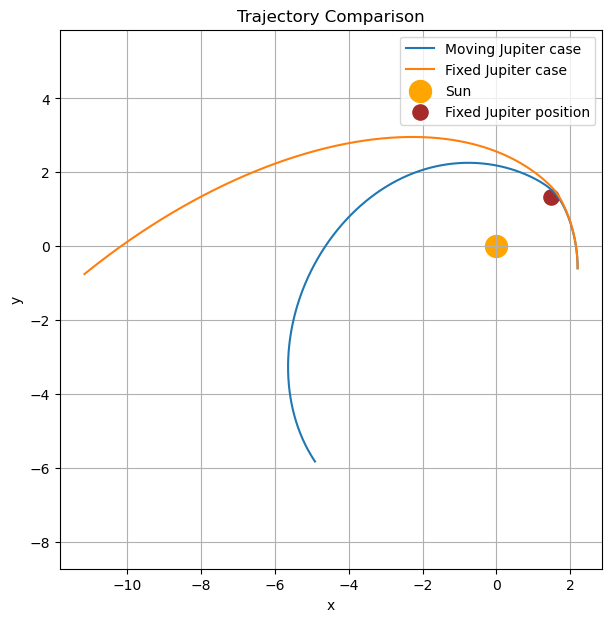

In [23]:
plt.figure(figsize=(7, 7))

plt.plot(x_list, y_list, label="Moving Jupiter case")
plt.plot(x_fixed_list, y_fixed_list, label="Fixed Jupiter case")
plt.scatter(0, 0, s=250, color="orange", label="Sun")
plt.scatter(xj_close, yj_close, s=120, color="brown", label="Fixed Jupiter position")

plt.axis("equal")
plt.grid()
plt.legend()
plt.title("Trajectory Comparison")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

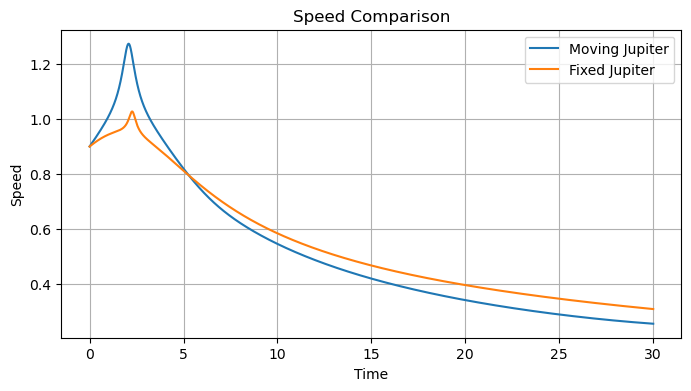

In [24]:
plt.figure(figsize=(8, 4))

plt.plot(time_list, speed_list, label="Moving Jupiter")
plt.plot(time_fixed_list, speed_fixed_list, label="Fixed Jupiter")

plt.grid()
plt.legend()
plt.title("Speed Comparison")
plt.xlabel("Time")
plt.ylabel("Speed")
plt.show()

In [25]:
print("Moving Jupiter:")
print("  initial speed =", speed_list[0])
print("  final speed   =", speed_list[-1])
print("  max speed     =", max(speed_list))

print("Fixed Jupiter:")
print("  initial speed =", speed_fixed_list[0])
print("  final speed   =", speed_fixed_list[-1])
print("  max speed     =", max(speed_fixed_list))

Moving Jupiter:
  initial speed = 0.9000980561852078
  final speed   = 0.2560369155143533
  max speed     = 1.2736636562732768
Fixed Jupiter:
  initial speed = 0.9000550012356072
  final speed   = 0.30931116096208505
  max speed     = 1.0274871061626163


## Result
移動する木星の場合と、最接近位置で固定した木星の場合で、
軌道と速度変化を比較した。

## Insight
移動木星の場合の方が最終地点での速度が落ちている．
これは木星の運動によるエネルギー交換の効果を示していると考えられる。

この比較では，最終地点の太陽との距離が異なるため，速度差の一部は位置エネルギーの違いかもしれない. そのため移動木星によって加速する例を探し，最終地点での太陽基準のエネルギーを比較したい．

In [26]:
results = []

# 探索範囲
x_range = np.linspace(0.5, 1.5, 5)
y_range = np.linspace(-2.0, -1.0, 5)
vx_range = np.linspace(0.6, 0.9, 4)
vy_range = np.linspace(0.5, 0.9, 4)

for x0 in x_range:
    for y0 in y_range:
        for vx0 in vx_range:
            for vy0 in vy_range:

                # --- Moving Jupiter ---
                x_list, y_list, xj_list, yj_list, speed_list, time_list, r_jup_list = simulate_flyby(
                    mu_sun, mu_jupiter, x0, y0, vx0, vy0, dt, steps
                )

                # 最接近取得
                closest_index = np.argmin(r_jup_list)
                xj_close = xj_list[closest_index]
                yj_close = yj_list[closest_index]

                # --- Fixed Jupiter ---
                x_fixed_list, y_fixed_list, speed_fixed_list, time_fixed_list, _ = simulate_flyby_fixed_jupiter(
                    mu_sun, mu_jupiter, x0, y0, vx0, vy0, dt, steps, xj_close, yj_close
                )

                # 最終速度比較（平均にしてもOK）
                final_moving = np.mean(speed_list[-1000:])
                final_fixed = np.mean(speed_fixed_list[-1000:])

                diff = final_moving - final_fixed

                results.append((diff, x0, y0, vx0, vy0))

# ソート（加速順）
results.sort(reverse=True)

In [44]:
# 上位10個（加速してるやつ）
for r in results[:100]:
    print(r)

(np.float64(258.63290142922256), np.float64(1.0), np.float64(-1.0), np.float64(0.6), np.float64(0.9))
(np.float64(22.55052372232709), np.float64(0.5), np.float64(-1.75), np.float64(0.7), np.float64(0.9))
(np.float64(8.259956719616897), np.float64(0.5), np.float64(-1.5), np.float64(0.8), np.float64(0.9))
(np.float64(2.5975887106813573), np.float64(0.5), np.float64(-1.0), np.float64(0.9), np.float64(0.5))
(np.float64(1.3563875433335992), np.float64(0.75), np.float64(-1.0), np.float64(0.8), np.float64(0.7666666666666666))
(np.float64(1.228063723598163), np.float64(0.5), np.float64(-2.0), np.float64(0.6), np.float64(0.9))
(np.float64(1.0295716227046612), np.float64(0.75), np.float64(-1.25), np.float64(0.7), np.float64(0.5))
(np.float64(0.9326013861755266), np.float64(0.75), np.float64(-1.25), np.float64(0.7), np.float64(0.9))
(np.float64(0.9216430439278624), np.float64(0.5), np.float64(-1.5), np.float64(0.7), np.float64(0.5))
(np.float64(0.7541030004230004), np.float64(0.5), np.float64(-1.

In [46]:
x0 = 0.5
y0 = -1.75
vx0 = 0.6
vy0 = 0.7666666666666666

In [47]:
x_list, y_list, xj_list, yj_list, speed_list, time_list, r_jup_list = simulate_flyby(
    mu_sun, mu_jupiter, x0, y0, vx0, vy0, dt, steps
)
closest_index = np.argmin(r_jup_list)
xj_close = xj_list[closest_index]
yj_close = yj_list[closest_index]
x_fixed_list, y_fixed_list, speed_fixed_list, time_fixed_list, r_fixed_jup_list = simulate_flyby_fixed_jupiter(
    mu_sun, mu_jupiter, x0, y0, vx0, vy0, dt, steps, xj_close, yj_close
)

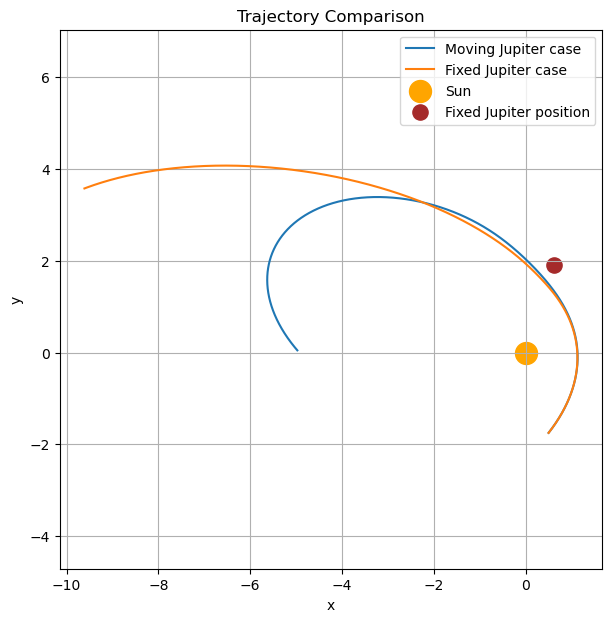

In [48]:
plt.figure(figsize=(7, 7))

plt.plot(x_list, y_list, label="Moving Jupiter case")
plt.plot(x_fixed_list, y_fixed_list, label="Fixed Jupiter case")
plt.scatter(0, 0, s=250, color="orange", label="Sun")
plt.scatter(xj_close, yj_close, s=120, color="brown", label="Fixed Jupiter position")

plt.axis("equal")
plt.grid()
plt.legend()
plt.title("Trajectory Comparison")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

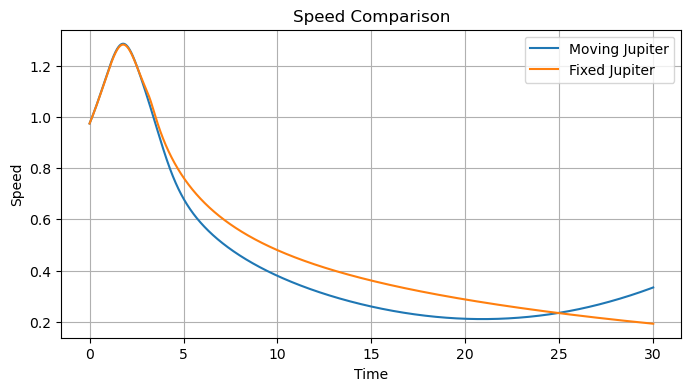

In [49]:
plt.figure(figsize=(8, 4))

plt.plot(time_list, speed_list, label="Moving Jupiter")
plt.plot(time_fixed_list, speed_fixed_list, label="Fixed Jupiter")

plt.grid()
plt.legend()
plt.title("Speed Comparison")
plt.xlabel("Time")
plt.ylabel("Speed")
plt.show()

適度な加速例が見つからなかったので，ふるいにかけることにする

In [50]:
results_good = []

x_range = np.linspace(0.4, 1.4, 9)
y_range = np.linspace(-2.0, -0.8, 13)
vx_range = np.linspace(0.6, 0.9, 7)
vy_range = np.linspace(0.5, 1.0, 11)

for x0 in x_range:
    for y0 in y_range:
        for vx0 in vx_range:
            for vy0 in vy_range:
                # moving Jupiter
                x_list, y_list, xj_list, yj_list, speed_list, time_list, r_jup_list = simulate_flyby(
                    mu_sun, mu_jupiter, x0, y0, vx0, vy0, dt, steps
                )

                min_r_jup = np.min(r_jup_list)
                max_speed = np.max(speed_list)

                # 近すぎ・速すぎを除外
                if min_r_jup < 0.1:
                    continue
                if max_speed > 2.5:
                    continue

                # 最接近時の木星位置を固定
                closest_index = np.argmin(r_jup_list)
                xj_close = xj_list[closest_index]
                yj_close = yj_list[closest_index]

                # fixed Jupiter
                x_fixed_list, y_fixed_list, speed_fixed_list, time_fixed_list, r_fixed_jup_list = simulate_flyby_fixed_jupiter(
                    mu_sun, mu_jupiter, x0, y0, vx0, vy0, dt, steps, xj_close, yj_close
                )

                moving_final_avg = np.mean(speed_list[-1000:])
                fixed_final_avg = np.mean(speed_fixed_list[-1000:])
                diff = moving_final_avg - fixed_final_avg

                # 適度な加速だけ残す
                if 0.2 < diff < 2.0:
                    results_good.append({
                        "diff": diff,
                        "x0": x0,
                        "y0": y0,
                        "vx0": vx0,
                        "vy0": vy0,
                        "min_r_jup": min_r_jup,
                        "max_speed": max_speed,
                        "moving_final_avg": moving_final_avg,
                        "fixed_final_avg": fixed_final_avg
                    })

# diff が小さい順に並べると「適度」な例を見やすい
results_good = sorted(results_good, key=lambda d: d["diff"])

print("number of good cases:", len(results_good))
for r in results_good[:20]:
    print(r)

number of good cases: 1033
{'diff': np.float64(0.20000483428406413), 'x0': np.float64(0.65), 'y0': np.float64(-0.8), 'vx0': np.float64(0.8500000000000001), 'vy0': np.float64(0.8500000000000001), 'min_r_jup': np.float64(0.4525657013692317), 'max_speed': np.float64(1.5014431667612362), 'moving_final_avg': np.float64(0.4634823863113261), 'fixed_final_avg': np.float64(0.263477552027262)}
{'diff': np.float64(0.20032509941387924), 'x0': np.float64(1.275), 'y0': np.float64(-0.9000000000000001), 'vx0': np.float64(0.65), 'vy0': np.float64(0.8500000000000001), 'min_r_jup': np.float64(0.4667095985170599), 'max_speed': np.float64(1.0700461025911616), 'moving_final_avg': np.float64(0.4309861418292629), 'fixed_final_avg': np.float64(0.23066104241538368)}
{'diff': np.float64(0.2006769828865399), 'x0': np.float64(0.525), 'y0': np.float64(-1.4), 'vx0': np.float64(0.9), 'vy0': np.float64(0.8500000000000001), 'min_r_jup': np.float64(0.26382185016073756), 'max_speed': np.float64(1.3251687500327207), 'movi